In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from stimugenerator import dataIO

In [2]:
hSML_dict = dataIO.unPickle("./opsins/human_SML_valid_NM.pkl")
print(hSML_dict.keys())
sts_nm = np.load('opsins/STS_nm.npy')

dict_keys(['s', 'm', 'l', 'nm', 'idx', 'sts_nm', 'sts_idx'])


In [11]:
sts_overlap_nm = hSML_dict['sts_nm'];print(sts_overlap_nm.shape)
sts_overlap_idx = hSML_dict['sts_idx']
opsin_overlap_nm = hSML_dict['nm'];print(opsin_overlap_nm.shape)
red = hSML_dict['l']
green = hSML_dict['m']
blue = hSML_dict['s']

(683,)
(887,)


In [12]:
def vline_max(x,y,c):
    max_nm = x[np.argmax(y)]
    label_nm = int(max_nm)
    plt.vlines(max_nm,0,1,color=c,label='{} nm'.format(label_nm))

## inspect the human opsin files

Text(0.5, 1.0, 'human opsin in the overlap wavelength area')

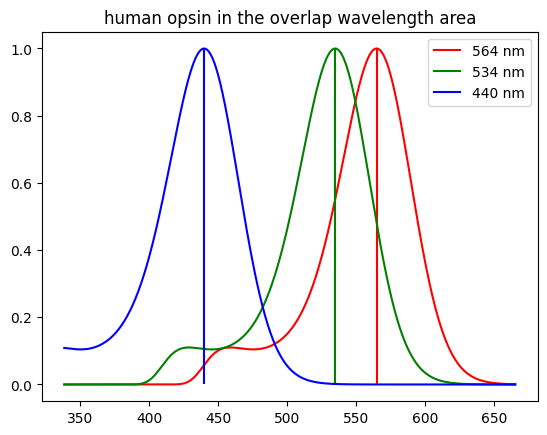

In [13]:
plt.plot(opsin_overlap_nm,red,color='r')
vline_max(opsin_overlap_nm,red,'r')
plt.plot(opsin_overlap_nm,green,color='g')
vline_max(opsin_overlap_nm,green,'g')
plt.plot(opsin_overlap_nm,blue,color='blue')
vline_max(opsin_overlap_nm,blue,'blue')
plt.legend()
plt.title("human opsin in the overlap wavelength area")

## inspect recordings from STS

In [21]:
pure_ = np.load("./test_2407_pure.npy") ## recording of a RGB printout, 0:red -> ?:green,->-1:blue
print(pure_.shape)

(20, 1024)


In [22]:
pure = pure_[:,sts_overlap_idx]
print(pure.shape)

(20, 683)


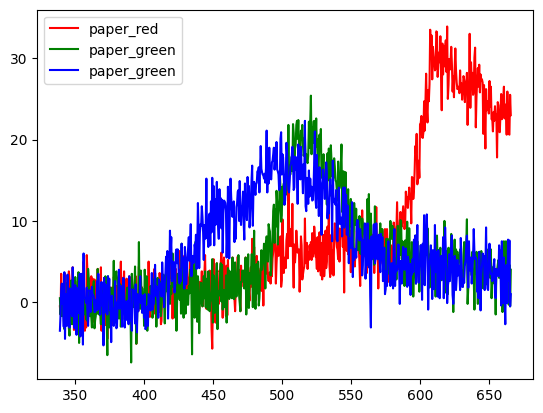

In [40]:
plt.plot(sts_overlap_nm,pure[0],color='r',label='paper_red')
plt.plot(sts_overlap_nm,pure[10],color='green',label='paper_green')
plt.plot(sts_overlap_nm,pure[-1],color='blue',label='paper_green')
plt.legend()

In [26]:
sts_overlap_nm.shape

(683,)

## color matching 

In [27]:
from scipy.interpolate import interp1d

# Example opsin sensitivity data (replace with your actual data)
opsin_wavelengths = opsin_overlap_nm
opsin_red = red
opsin_green = green
opsin_blue = blue

# Interpolating the opsin sensitivities to match the provided wavelengths
interpolator_red = interp1d(opsin_wavelengths, opsin_red, kind='linear', bounds_error=False, fill_value=0)
interpolator_green = interp1d(opsin_wavelengths, opsin_green, kind='linear', bounds_error=False, fill_value=0)
interpolator_blue = interp1d(opsin_wavelengths, opsin_blue, kind='linear', bounds_error=False, fill_value=0)

In [29]:
# Provided wavelengths
wavelengths = sts_overlap_nm

# Interpolated opsin sensitivities
opsin_red_interp = interpolator_red(wavelengths)
opsin_green_interp = interpolator_green(wavelengths)
opsin_blue_interp = interpolator_blue(wavelengths)

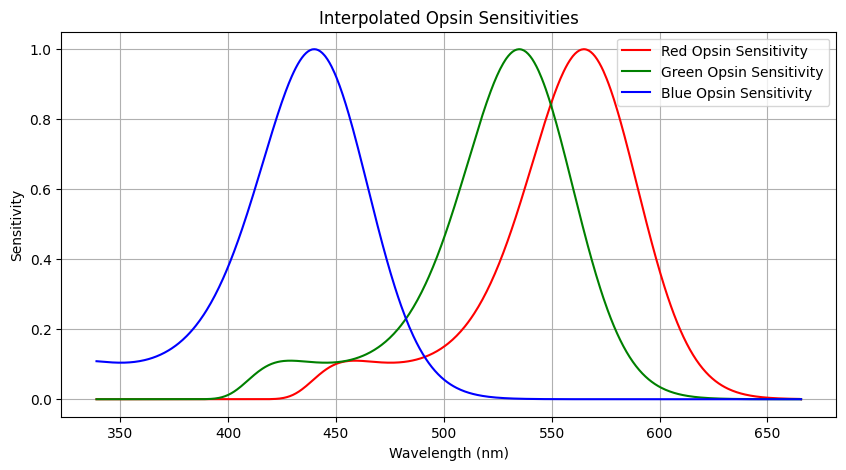

In [31]:
# Plot the interpolated opsin sensitivities to verify
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, opsin_red_interp, label='Red Opsin Sensitivity',color='r')
plt.plot(wavelengths, opsin_green_interp, label='Green Opsin Sensitivity',color='g')
plt.plot(wavelengths, opsin_blue_interp, label='Blue Opsin Sensitivity',color='blue')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Sensitivity')
plt.title('Interpolated Opsin Sensitivities')
plt.legend()
plt.grid(True)
plt.show()


In [32]:
# Compute RGB values using the interpolated opsin sensitivities
def spectral_to_rgb(spectral_data, opsin_red, opsin_green, opsin_blue):
    R = np.sum(spectral_data * opsin_red, axis=-1)
    G = np.sum(spectral_data * opsin_green, axis=-1)
    B = np.sum(spectral_data * opsin_blue, axis=-1)
    return R, G, B

In [34]:
# Load spectral data
spectral_data = np.load("./test_2407_pure.npy")[:,sts_overlap_idx]
R, G, B = spectral_to_rgb(spectral_data, opsin_red_interp, opsin_green_interp, opsin_blue_interp)

In [36]:
# Normalize the RGB values
R_norm = R / np.max(R)
G_norm = G / np.max(G)
B_norm = B / np.max(B)

# Stack RGB values to form the RGB image
RGB = np.stack([R_norm, G_norm, B_norm], axis=-1)

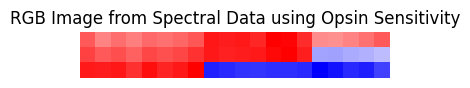

In [43]:
# Display the RGB image
plt.figure(figsize=(4, 1))
plt.imshow(RGB[::-1].transpose(),cmap='bwr')
plt.title('RGB Image from Spectral Data using Opsin Sensitivity')
plt.axis('off')
plt.show()


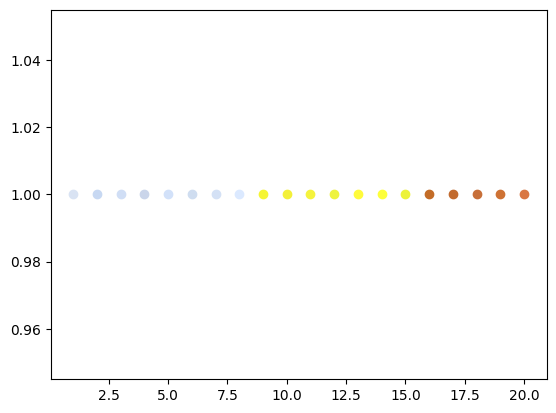

In [38]:
for i in range(20):
    plt.scatter(20-i,1,color=RGB[i])

### just in case, overlap meaning

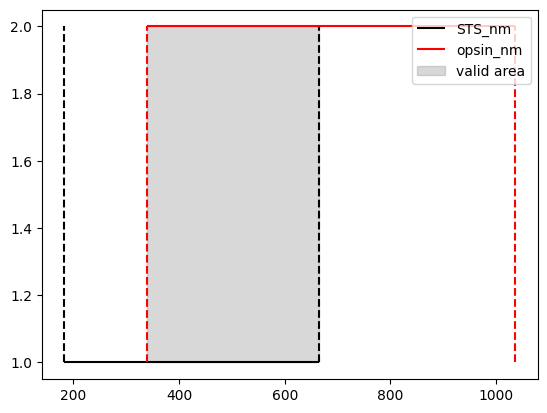

In [51]:
plt.hlines(1,np.min(sts_nm),np.max(sts_nm),color='k',label='STS_nm')
plt.vlines(np.min(sts_nm),1,2,color='k',linestyle='dashed')
plt.vlines(np.max(sts_nm),1,2,color='k',linestyle='dashed')

plt.hlines(2,np.min(opsin_nm),np.max(opsin_nm),color='r',label='opsin_nm')
plt.vlines(np.min(opsin_nm),1,2,color='r',linestyle='dashed')
plt.vlines(np.max(opsin_nm),1,2,color='r',linestyle='dashed')

plthuman.fill_betweenx([1,2],np.min(opsin_nm),np.max(sts_nm),color='gray',alpha=.3,label='valid area')
plt.legend()